<a href="https://colab.research.google.com/github/rialdcart098/bengio-glorot-2010/blob/main/paper_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

Using device cuda


In [2]:
class MLP(nn.Module):
  def __init__(self, activation):
    super().__init__()
    self.flatten = nn.Flatten()
    self.layers = nn.ModuleList([
        nn.Sequential(nn.Linear(28 * 28, 1000), activation),
        nn.Sequential(nn.Linear(1000, 1000), activation),
        nn.Sequential(nn.Linear(1000, 1000), activation),
        nn.Sequential(nn.Linear(1000, 1000), activation),
    ])
    self.out_layer = nn.Linear(1000, 10)
    self.softmax = nn.LogSoftmax(dim=1)
  def forward(self, x):
    x = self.flatten(x)
    for layer in self.layers:
      x = layer(x)
    x = self.out_layer(x)
    return self.softmax(x)

### Section 3.1: Experiments with the Sigmoid

I decided to use MNIST for this, however I only use $20000 \cdot 20$ epochs due to it being a much easier dataset than Shapeset 3x2


In [3]:
transform_sigmoid = transforms.Compose([
    transforms.ToTensor()
])

In [4]:

train_set = MNIST(root='./data', train=True, download=True, transform=transform_sigmoid)
test_set = MNIST(root='./data', train=False, download=True, transform=transform_sigmoid)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=10, shuffle=True, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=300, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.54MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


In [5]:
fixed_imgs, fixed_labels = next(iter(test_loader))
fixed_imgs, fixed_labels = fixed_imgs.to(device), fixed_labels.to(device)

In [6]:
def lecun_init(layer):
  if isinstance(layer, nn.Linear):
    n = layer.in_features
    a = n ** -0.5
    nn.init.uniform_(layer.weight, -a, a)
    nn.init.zeros_(layer.bias)

In [7]:
model = MLP(activation=nn.Sigmoid()).to(device)
model.apply(lecun_init)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=784, out_features=1000, bias=True)
      (1): Sigmoid()
    )
    (1-3): 3 x Sequential(
      (0): Linear(in_features=1000, out_features=1000, bias=True)
      (1): Sigmoid()
    )
  )
  (out_layer): Linear(in_features=1000, out_features=10, bias=True)
  (softmax): LogSoftmax(dim=1)
)

In [8]:
def train3_1(model, epochs=20_000 * 20, lr=0.1):

  optimizer = torch.optim.SGD(model.parameters(), lr=lr)
  loss_fn = nn.NLLLoss()
  act_curve = {f"Layer {i}": {"mean": [], "std": []} for i in range(1, 5)}
  steps = 0
  train_losses = []
  validation_losses = []
  def make_hook(layer_name):
    def hook(module, input, output):
      act = output.detach()
      act_curve[layer_name]['mean'].append(act.mean().item())
      act_curve[layer_name]['std'].append(act.std().item())
    return hook

  def record_activations(train_loss=999):
    model.eval()
    hooks = [
      layer.register_forward_hook(make_hook(f"Layer {i + 1}"))
      for i, layer in enumerate(model.layers)
    ]

    with torch.no_grad():
      val_loss = loss_fn(model(fixed_imgs), fixed_labels)
      validation_losses.append(val_loss.item())
      print(f"step {steps}/{epochs} | train loss: {train_loss:.4f} | val loss: {val_loss.item():.4f}")
    for h in hooks:
      h.remove()

  record_activations()
  while steps < epochs:
    for images, labels in train_loader:
      model.train()
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      loss = loss_fn(model(images), labels)
      loss.backward()
      optimizer.step()
      steps += 1
      if steps % 20_000 == 0:
        train_losses.append(loss.item())
        record_activations(loss.item())

      if steps >= epochs:
        break
  return train_losses, validation_losses, act_curve

In [9]:
train_losses, val_losses, act_curve = train3_1(model, lr=0.01)

step 0/400000 | train loss: 999.0000 | val loss: 2.3093
step 20000/400000 | train loss: 2.2962 | val loss: 2.3101
step 40000/400000 | train loss: 2.3162 | val loss: 2.3078
step 60000/400000 | train loss: 2.3216 | val loss: 2.3049
step 80000/400000 | train loss: 2.2871 | val loss: 2.2975
step 100000/400000 | train loss: 2.3119 | val loss: 2.3003
step 120000/400000 | train loss: 2.2909 | val loss: 2.2961
step 140000/400000 | train loss: 2.3080 | val loss: 2.2976
step 160000/400000 | train loss: 2.3127 | val loss: 2.2976
step 180000/400000 | train loss: 2.3056 | val loss: 2.2983
step 200000/400000 | train loss: 2.2708 | val loss: 2.3036
step 220000/400000 | train loss: 2.3140 | val loss: 2.3014
step 240000/400000 | train loss: 2.3420 | val loss: 2.2973
step 260000/400000 | train loss: 2.3200 | val loss: 2.2985
step 280000/400000 | train loss: 2.2965 | val loss: 2.2919
step 300000/400000 | train loss: 2.1729 | val loss: 2.2076
step 320000/400000 | train loss: 1.5330 | val loss: 1.7120
step

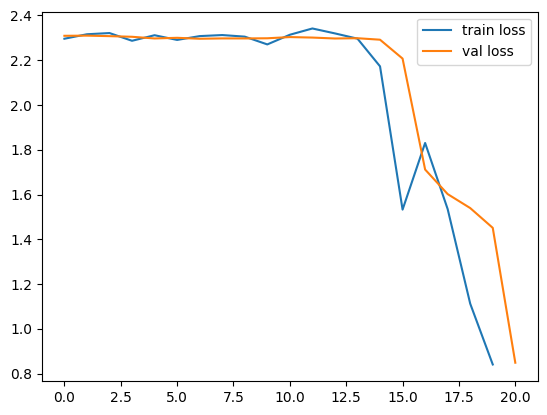

In [10]:
plt.plot(range(len(train_losses)), train_losses)
plt.plot(range(len(val_losses)), val_losses)
plt.legend(['train loss', 'val loss'])

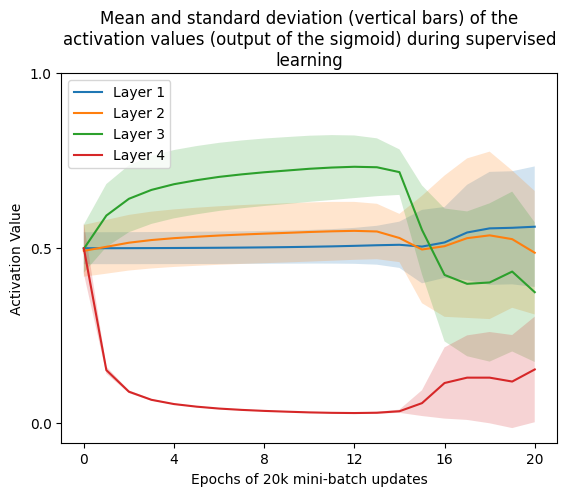

In [ ]:
lines = []
for name, activations in act_curve.items():
  line, = plt.plot(
      range(len(activations['mean'])),
      activations['mean'][:21]
  )
  means = np.array(activations['mean'])
  stds = np.array(activations['std'])
  lines.append(line)
  plt.fill_between(range(len(activations['mean'])), means + stds, means - stds, alpha=0.2)
plt.legend(lines, act_curve.keys())
plt.title("""Mean and standard deviation (vertical bars) of the
activation values (output of the sigmoid) during supervised
learning""")
plt.xlabel("Epochs of 20k mini-batch updates")
plt.ylabel("Activation Value")
plt.yticks([0, 0.5, 1])
plt.xticks(range(0, 21, 20 // 5))
plt.show()

### 3.2: Experiments with the Hyperbolic tangent

In [ ]:
tanh_model = MLP(nn.Tanh()).to(device)
tanh_model.apply(lecun_init)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=784, out_features=1000, bias=True)
      (1): Tanh()
    )
    (1-3): 3 x Sequential(
      (0): Linear(in_features=1000, out_features=1000, bias=True)
      (1): Tanh()
    )
  )
  (out_layer): Linear(in_features=1000, out_features=10, bias=True)
  (softmax): LogSoftmax(dim=1)
)